# Project 3
Analysis of grades in high schools in Oslo for the time-period 2007/2008 to 2024/2025. We look at the exam grades, oral and written. The analysis is based on theese subjects:

**From Mathematics and Natural Sciences:**
- physics 1 and 2 
- mathematics R1 and R2 
- chemistry 1 and 2 

**From manditory subjects:**
- mathematics 1T, 1P and 2P
- natural science
- english
- social sciences
- geography
- history
- religion


In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("selektert_Karakterer_i_videregaaende_skole.csv", encoding='utf-16-le', sep="\t", skiprows=1)
columns_drop = ["FagNivaa", "EnhetNivaa", "Vurderingsfagnavn", "Nasjonaltkode", "Organisasjonsnummer", "Nasjonalt"]
data = data.drop(columns=columns_drop)

#print(data.columns)

/tmp/ipykernel_3746/3064108530.py:5: DtypeWarning: Columns (0: 2007-08.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter, 1: 2007-08.Muntlig eksamen.Alle eierformer.Alle kjønn.Antall elever, 2: 2007-08.Muntlig eksamen.Alle eierformer.Gutt.Snittkarakter, 3: 2007-08.Muntlig eksamen.Alle eierformer.Gutt.Antall elever, 4: 2007-08.Muntlig eksamen.Alle eierformer.Jente.Snittkarakter, 5: 2007-08.Muntlig eksamen.Alle eierformer.Jente.Antall elever, 6: 2007-08.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter, 7: 2007-08.Skriftlig eksamen.Alle eierformer.Alle kjønn.Antall elever, 8: 2007-08.Skriftlig eksamen.Alle eierformer.Gutt.Snittkarakter, 9: 2007-08.Skriftlig eksamen.Alle eierformer.Gutt.Antall elever, 10: 2007-08.Skriftlig eksamen.Alle eierformer.Jente.Snittkarakter, 11: 2007-08.Skriftlig eksamen.Alle eierformer.Jente.Antall elever, 12: 2007-08.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter, 13: 2007-08.Standpunkt.Alle eierformer.Alle kjønn.Antall elever, 14: 2007-08.

#### Making a dataset consisting of only the schools in Oslo.

In [125]:
oslo_data = data[data['Fylkekode'] == 3]
#oslo_data.to_csv("selektert_oslo.csv", index=False, encoding="utf-8")

#### Making new names of columns
Shorter and easier to read, and easier to do data analysis on.

In [126]:
# Gir kolonnene nye og kortere lesbare navn

map_geographic = {
    "Vurderingsfagkode": "Fagkode",
    "Fylkekode": "Fylkekode",
    "Fylke": "Fylke",
    "EnhetNavn": "Skolenavn"
}

map_evaluation = {
    "Skriftlig eksamen": "SE",
    "Muntlig eksamen": "ME",
    "Standpunkt": "SP"
}

map_gender = {
    "Alle kjønn": "AK",
    "Gutt": "G",
    "Jente": "J"
}

map_grades = {
    "Snittkarakter": "SK",
    "Antall elever": "AE",
    "Snittkarakter.Brudd": "SK.Brudd",
    "Antall elever.Brudd": "AE.Brudd"
}

def rename(col):
    if col in map_geographic:
        return map_geographic[col]
    
    parts = col.split(".")

    year = parts[0]
    type = parts[1]
    gender = parts[3]
    grade = ".".join(parts[4:]) # for the "Brudd"-stuff

    return f"{year}.{map_evaluation.get(type, type)}.{map_gender.get(gender, gender)}.{map_grades.get(grade, grade)}"

oslo_data.columns = [rename(c) for c in oslo_data.columns]

#print(oslo_data.columns)


#### Mapping the subjects to their respective code.
Just so it is easier for us to read.

In [127]:
fag = {
    "REA3004": "Fysikk 1", # 2008-2022
    "REA3038": "Fysikk 1", # 2022-
    "REA3005": "Fysikk 2", # 2009-2023
    "REA3039": "Fysikk 2", # 2023-
    "REA3022": "Matematikk R1", # 2008-2022
    "REA3056": "Matematikk R1", #2022-
    "REA3024": "Matematikk R2", # 2009-2023
    "REA3058": "Matematikk R2", #2023-
    "REA3011": "Kjemi 1", # 2008-2022
    "REA3045": "Kjemi 1", # 2022-
    "REA3012": "Kjemi 2", # 2009-2023
    "REA3046": "Kjemi 2", # 2023-
    "MAT1013": "Matematikk 1T", # 2010-H2021
    "MAT1021": "Matematikk 1T", # 2021- 
    "MAT1011": "Matematikk 1P", # 2010-H2021
    "MAT1019": "Matematikk 1P", # 2021-
    "MAT1015": "Matematikk 2P", # 2011-2022
    "MAT1023": "Matematikk 2P", # 2022-
    "ENG1002": "Engelsk, vg1 studieforberedende utdanningsprogram", # 2007-H2021
    "ENG1007": "Engelsk vg1 studieforberedende utdanningsprogram", # 2021
    "SAF1001": "Samfunnsfag", # 2007-H2022
    "SAK1001": "Samfunnskunnskap", # 2021-
    "GEO1001": "Geografi", # 2007-2021
    "GEO1003": "Geografi", # 2021-
    "HIS1002": "Historie vg3 studieforberedende utdanningsprogram", # 2009-2023
    "HIS1010": "Historie Vg3 studieforberedende utdanningsprogram", # 2023
    "REL1001": "Religion og etikk", # 2009-2023
    "REL1003": "Religion og etikk", # 2023-
    "NAT1002": "Naturfag, vg1 studieforberedende utdanningsprogram", # 2007-2021
    "NAT1007": "Naturfag vg1 studieforberedende utdanningsprogram", ## 2021
}

Be aware of 

*"Fra og med skoleåret 2012-2013, endret beregningsgrunnlag for karakterstatistikken, skriftlig eksamen."*

### Removing columns with "Brudd"

These columns contain the meassage written in italic over. I want to remove them so that I can handle columns with numbers only.

In [128]:
drop = [c for c in oslo_data.columns if "Brudd" in c]

oslo_data = oslo_data.drop(columns=drop)

### Making all columns into float
And substituting all string-numbers with comma, into string-numbers with a period. 

"4,5" ==> "4.5"

In [129]:
# substituting
oslo_data = oslo_data.replace(",", ".", regex=True)

# making all strings into float, and everything that cannot be converted into float, into NaN.
first = oslo_data.iloc[:, :4]
rest = oslo_data.iloc[:, 4:].apply(pd.to_numeric, errors="coerce")
oslo_data = pd.concat([first, rest], axis=1)

#print(oslo_data)

### Ready to make some plots. This is what I want to plot

- gjennomsnitt av karakterer for alle fag, alle år, alle skoler
- splitte realfag og fellesfag, alle år, alle skoler
- splitte alle fag, alle år, alle skoler
- alle fag, alle år, spesifikke skoler
- splitte realfag og fellesfag, alle år, spesifikke skoler
- splitte jenter og gutter, alle skoler, alle fag
- splitte jenter og gutter, alle skoler, splitte realfag og fellesfag
- antall som tar eksamen/sandpunkt hvert år
- antall som tar eksamen/standpunkt/begge realfag hvert år
- antall som tar eksamen/standpunkt/begge fellesfag hvert år


#### First plot is the mean of grades for all subjects for all schools per year

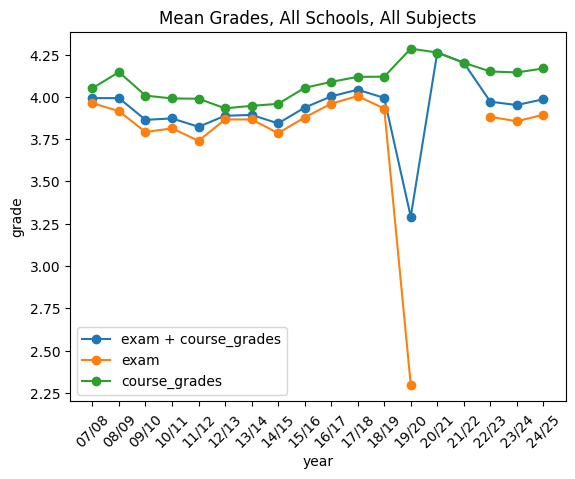

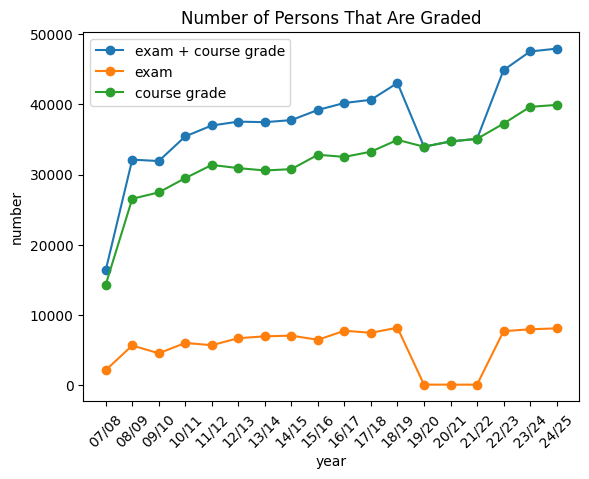

In [ ]:
# take out all columns with "snittkarakter"
sk = [c for c in oslo_data.columns if ".SK" in c and ".AK" in c] # sk=snittkarakter
mse = [c for c in oslo_data.columns if ".SK" in c and ".AK" in c and (".ME" in c or ".SE" in c)] # mse=muntlig skriftlig eksamen
sp = [c for c in oslo_data.columns if ".SK" in c and ".AK" in c and ".SP" in c] # sp=standpunkt
ae = [c for c in oslo_data.columns if ".AE" in c and ".AK" in c] # ae=antall elever
course = [c for c in oslo_data.columns if ".AE" in c and ".SP" in c and ".AK" in c] # antall elever med standpunkt
exam = [c for c in oslo_data.columns if ".AE" in c and ".AK" in c and (".ME" in c or ".SE" in c)] # antall elever til eksamen

# making list for plotting
liste = []
liste_ex = []
liste_cg = []
number = []
exams = []
course_grade = []
years = []
# 
for i in range(7, 25):
    # mean of all grades
    sort_cols_all = [c for c in sk if f"200{i}" in c or f"20{i}" in c]
    liste.append(oslo_data[sort_cols_all].mean().mean())

    sort_cols_list_ex = [c for c in mse if f"200{i}" in c or f"20{i}" in c]
    liste_ex.append(oslo_data[sort_cols_list_ex].mean().mean())

    sort_cols_list_cg = [c for c in sp if f"200{i}" in c or f"20{i}" in c]
    liste_cg.append(oslo_data[sort_cols_list_cg].mean().mean())
    
    # making year-list
    if i < 9:
        years.append(f"0{i}/0{i+1}")
    elif i == 9:
        years.append(f"0{i}/{i+1}")
    elif i > 9:
        years.append(f"{i}/{i+1}")

    # all persons getting a grade
    sort_cols_number = [c for c in ae if f"200{i}" in c or f"20{i}" in c]
    number.append(oslo_data[sort_cols_number].sum().sum())

    # all persons taking an exam
    sort_cols_exam = [c for c in exam if f"200{i}" in c or f"20{i}" in c]
    exams.append(oslo_data[sort_cols_exam].sum().sum())

    # all persons which took the course
    sort_cols_course = [c for c in course if f"200{i}" in c or f"20{i}" in c]
    course_grade.append(oslo_data[sort_cols_course].sum().sum())
   

plt.plot(years, liste, marker="o", label="exam + course_grades")
plt.plot(years, liste_ex, marker="o", label="exam")
plt.plot(years, liste_cg, marker="o", label="course_grades")
plt.title("Mean Grades, All Schools, All Subjects")
plt.xlabel("year")
plt.ylabel("grade")
plt.legend()
plt.xticks(rotation=45)
plt.show()

plt.plot(years, number, marker="o", label='exam + course grade')
plt.plot(years, exams, marker="o", label='exam')
plt.plot(years, course_grade, marker="o", label='course grade')
plt.xticks(rotation=45)
plt.title("Number of Persons That Are Graded")
plt.xlabel("year")
plt.ylabel("number")
plt.legend()
plt.show()

#### Second is splitting of natural sciences and common subjects

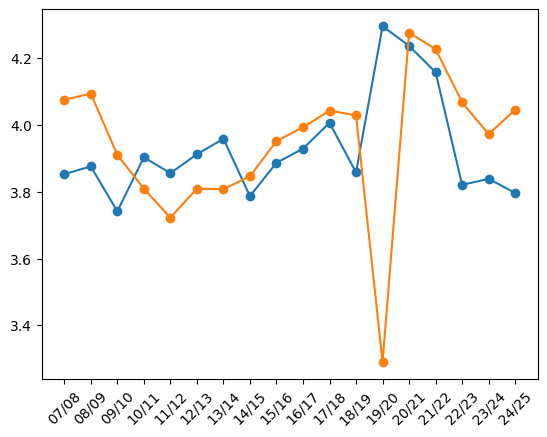

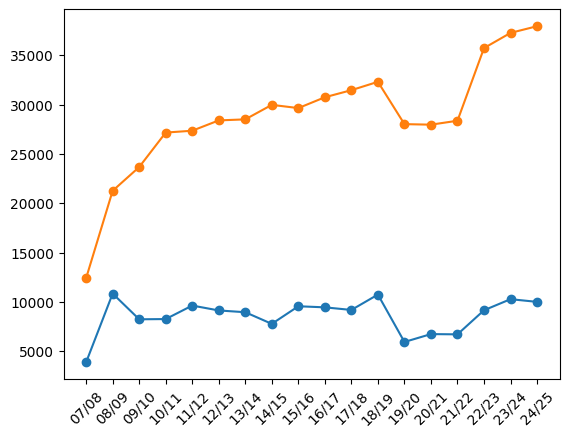

In [ ]:
realfag = ["REA3004", "REA3038", "REA3005", "REA3039", "REA3022", "REA3056",
           "REA3024", "REA3058", "REA3011", "REA3045", "REA3012", "REA3046"]

sk = [c for c in oslo_data.columns if ".SK" in c and ".AK" in c] # sk=snittkarakter
ae_sk = [c for c in oslo_data.columns if ".AE" in c and ".AK" in c] # ae_sk=antall elever snittkarakter


re_rows = oslo_data[oslo_data["Fagkode"].isin(realfag)] # re_rows=realfag rader
re = re_rows[sk]
ae_re = re_rows[ae_sk]

fe_rows = oslo_data[~oslo_data["Fagkode"].isin(realfag)] # fe_rows=fellesfag rader
fe = fe_rows[sk]
ae_fe = fe_rows[ae_sk]



realfag = []
antall_re = []
fellesfag = []
antall_fe = []

for i in range(7, 25):
    # mean of all science grades
    sort_cols_all = [c for c in re if f"200{i}" in c or f"20{i}" in c]
    realfag.append(re[sort_cols_all].mean().mean())

    sort_cols_all = [c for c in ae_re if f"200{i}" in c or f"20{i}" in c]
    antall_re.append(ae_re[sort_cols_all].sum().sum())

    sort_cols_all = [c for c in fe if f"200{i}" in c or f"20{i}" in c]
    fellesfag.append(fe[sort_cols_all].mean().mean())

    sort_cols_all = [c for c in ae_fe if f"200{i}" in c or f"20{i}" in c]
    antall_fe.append(ae_fe[sort_cols_all].sum().sum())

plt.plot(years, realfag, marker="o", label="realfag")
plt.plot(years, fellesfag, marker="o", label="fellesfag")
plt.xticks(rotation=45)
plt.title("Mean Grades, All Schools, Splitting of Subjects")
plt.xlabel("year")
plt.ylabel("grade")
plt.legend()
plt.show()

plt.plot(years, antall_re, marker="o", label="realfag")
plt.plot(years, antall_fe, marker="o", label="fellesfag")
plt.xticks(rotation=45)
plt.title("Number of Persons that are Graded")
plt.xlabel("year")
plt.ylabel("number")
plt.legend()
plt.show()